```
Dataset
   ↓
EDA (explore dataset)
   ↓
Data preprocessing
   ↓
Dataset + DataLoader
   ↓
Model architecture
   ↓
Training loop
   ↓
Evaluation metrics
   ↓
Visualization prediction
   ↓
Model improvement
```

In [1]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.9 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

In [3]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import pandas as pd

# Dataset

# EDA (explore dataset)

In [5]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt

# =======================
# 1. LOAD CLASS MAPPING
# =======================
BASE_DIR = "/kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1"

df = pd.read_csv(os.path.join(BASE_DIR, "class_mapping.csv"))

seg_part = df.iloc[:, 3:5]
seg_part.columns = ['Class Index', 'Class Name']
seg_part = seg_part.dropna(subset=['Class Index'])
seg_part = seg_part[seg_part['Class Index'].astype(str).str.isnumeric()]

class_mapping = seg_part.reset_index(drop=True)
class_mapping['Class Index'] = class_mapping['Class Index'].astype(int)

NUM_CLASSES = len(class_mapping)

print(class_mapping)
print("Num classes:", NUM_CLASSES)


# =======================
# 2. LOAD TRAIN DATA (398)
# =======================
TRAIN_PATH = os.path.join(BASE_DIR, "Train", "Labeled")
categories = ["Flooded", "Non-Flooded"]

train_imgs, train_masks = [], []

for cat in categories:
    img_dir = os.path.join(TRAIN_PATH, cat, "image")
    mask_dir = os.path.join(TRAIN_PATH, cat, "mask")

    for file in os.listdir(img_dir):
        img_path = os.path.join(img_dir, file)
        mask_path = os.path.join(mask_dir, file.replace(".jpg", "_lab.png"))

        if os.path.exists(mask_path):
            train_imgs.append(img_path)
            train_masks.append(mask_path)

print("Train samples:", len(train_imgs))


# =======================
# 3. LOAD VAL DATA (MATCH ID)
# =======================
VAL_IMG_DIR = "/kaggle/input/datasets/catashiro31/floodnet-dataset-for-segmentation-fixed-mask/data_finally/val/image"
VAL_MASK_DIR = "/kaggle/input/datasets/catashiro31/floodnet-dataset-for-segmentation-fixed-mask/data_finally/val/mask"

val_image_paths = []
val_mask_paths = []

# Tạo dict mask theo ID
mask_dict = {f.split(".")[0]: f for f in os.listdir(VAL_MASK_DIR)}

# Match theo ID
for img_file in os.listdir(VAL_IMG_DIR):
    img_id = img_file.split(".")[0]
    if img_id in mask_dict:
        val_image_paths.append(os.path.join(VAL_IMG_DIR, img_file))
        val_mask_paths.append(os.path.join(VAL_MASK_DIR, mask_dict[img_id]))

print("Matched val samples:", len(val_image_paths))


# =======================
# 4. SPLIT VAL -> VAL + TEST
# =======================
val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    val_image_paths,
    val_mask_paths,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

print("\nFinal Split:")
print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))

   Class Index            Class Name
0            0            Background
1            1      Building-flooded
2            2  Building-non-flooded
3            3          Road-flooded
4            4      Road-non-flooded
5            5                 Water
6            6                  Tree
7            7               Vehicle
8            8                  Pool
9            9                 Grass
Num classes: 10
Train samples: 398
Matched val samples: 81

Final Split:
Train: 398
Val: 56
Test: 25


In [6]:
def count_images_per_class(mask_paths):
    class_count = {i: 0 for i in range(NUM_CLASSES)}

    for m in mask_paths:
        mask = np.array(Image.open(m))
        unique_classes = np.unique(mask)

        for c in unique_classes:
            class_count[int(c)] += 1

    return class_count

In [7]:
# train_img_dist = count_images_per_class(train_masks)
# val_img_dist   = count_images_per_class(val_masks)
# test_img_dist  = count_images_per_class(test_masks)

# print("Train:", train_img_dist)
# print("Val:", val_img_dist)
# print("Test:", test_img_dist)

In [8]:
# class_names = class_mapping['Class Name'].tolist()

# def plot_all_in_one_row(train_dist, val_dist, test_dist):
#     values_train = [train_dist[i] for i in range(NUM_CLASSES)]
#     values_val   = [val_dist[i] for i in range(NUM_CLASSES)]
#     values_test  = [test_dist[i] for i in range(NUM_CLASSES)]

#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 hàng, 3 cột

#     datasets = [
#         ("Train", values_train),
#         ("Validation", values_val),
#         ("Test", values_test)
#     ]

#     for ax, (title, values) in zip(axes, datasets):
#         bars = ax.bar(class_names, values)

#         ax.set_title(title)
#         ax.set_ylabel("Number of Images")
#         ax.tick_params(axis='x', rotation=45)

#         # Hiển thị số trên cột
#         for bar in bars:
#             height = bar.get_height()
#             ax.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 height,
#                 str(int(height)),
#                 ha='center',
#                 va='bottom',
#                 fontsize=8
#             )

#     plt.tight_layout()
#     plt.show()


# plot_all_in_one_row(train_img_dist, val_img_dist, test_img_dist)

# Data preprocessing

In [9]:
import numpy as np
from collections import defaultdict, Counter
from PIL import Image
from tqdm import tqdm

def build_class_to_images(mask_paths):
    class_to_images = defaultdict(list)

    for idx, m in enumerate(tqdm(mask_paths, desc="Scanning masks")):
        mask = np.array(Image.open(m))
        unique_classes = np.unique(mask)

        for c in unique_classes:
            class_to_images[int(c)].append(idx)

    return class_to_images

def oversample_segmentation(train_imgs, train_masks, target_ratio=1.0):
    class_to_images = build_class_to_images(train_masks)

    class_counts = {c: len(idxs) for c, idxs in class_to_images.items()}
    max_count = max(class_counts.values())
    target_count = int(max_count * target_ratio)

    print("\nBefore oversampling:")
    for c in range(NUM_CLASSES):
        print(f"Class {c}: {class_counts.get(c, 0)}")

    oversampled_indices = []
    oversample_flags = []

    # ✅ Thêm data gốc
    for i in range(len(train_imgs)):
        oversampled_indices.append(i)
        oversample_flags.append(False)   # 👈 QUAN TRỌNG

    # ✅ Oversample
    for c in range(NUM_CLASSES):
        indices = class_to_images.get(c, [])
        current_count = len(indices)

        if current_count == 0:
            continue

        if current_count < target_count:
            need = target_count - current_count
            extra = np.random.choice(indices, size=need, replace=True)

            for idx in extra:
                oversampled_indices.append(idx)
                oversample_flags.append(True)   # 👈 QUAN TRỌNG

    # Build dataset
    new_imgs = [train_imgs[i] for i in oversampled_indices]
    new_masks = [train_masks[i] for i in oversampled_indices]

    print(f"\nTotal images after oversampling: {len(new_imgs)}")
    print(f"Total flags: {len(oversample_flags)}")

    return new_imgs, new_masks, oversample_flags

In [10]:
def count_images_per_class(mask_paths):
    class_count = {i: 0 for i in range(NUM_CLASSES)}

    for m in tqdm(mask_paths, desc="Counting"):
        mask = np.array(Image.open(m))
        unique_classes = np.unique(mask)

        for c in unique_classes:
            class_count[int(c)] += 1

    return class_count

In [11]:
oversampled_imgs, oversampled_masks, oversample_flags = oversample_segmentation(
    train_imgs, train_masks, target_ratio=1.0
)

# new_dist = count_images_per_class(oversampled_masks)

# print("\nAfter oversampling:")
# print(new_dist)

Scanning masks: 100%|██████████| 398/398 [01:58<00:00,  3.35it/s]


Before oversampling:
Class 0: 29
Class 1: 36
Class 2: 142
Class 3: 37
Class 4: 194
Class 5: 187
Class 6: 311
Class 7: 126
Class 8: 88
Class 9: 368

Total images after oversampling: 2560
Total flags: 2560


In [12]:
print(len(oversampled_imgs))
print(len(oversampled_masks))
print(len(oversample_flags))

2560
2560
2560


In [13]:
# def plot_before_after(train_dist, new_dist):
#     values_before = [train_dist[i] for i in range(NUM_CLASSES)]
#     values_after  = [new_dist[i] for i in range(NUM_CLASSES)]

#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 hàng, 2 cột

#     datasets = [
#         ("Before Oversampling", values_before),
#         ("After Oversampling", values_after)
#     ]

#     for ax, (title, values) in zip(axes, datasets):
#         bars = ax.bar(class_names, values)

#         ax.set_title(title)
#         ax.set_ylabel("Number of Images")
#         ax.tick_params(axis='x', rotation=45)

#         # Hiển thị số trên cột
#         for bar in bars:
#             height = bar.get_height()
#             ax.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 height,
#                 str(int(height)),
#                 ha='center',
#                 va='bottom',
#                 fontsize=8
#             )

#     plt.tight_layout()
#     plt.show()

# plot_before_after(train_img_dist, new_dist)

In [14]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

aug_normal  = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.1, 0.1),
        rotate=(-30, 30),
        p=0.5
    ),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    # A.GaussNoise(p=0.2),
    # A.CoarseDropout(
    #     num_holes_range=(1, 8),
    #     hole_height_range=(16, 64),
    #     hole_width_range=(16, 64),
    #     p=0.5
    # ),
    # A.HueSaturationValue(p=0.3),
    A.RandomGamma(p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], is_check_shapes=False)


aug_strong = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(translate_percent=0.1, scale=(0.8, 1.2), rotate=(-45, 45), p=0.7),
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.4),
    A.OneOf([
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.5),
        A.CLAHE(p=0.5),
    ], p=0.5),
    A.Resize(512, 512),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])



val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], is_check_shapes=False)

In [15]:
from torch.utils.data import Dataset

class BalancedFloodDataset(Dataset):
    def __init__(self, image_paths, mask_paths, oversample_flags):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.flags = oversample_flags

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
    
        if img is None or mask is None:
            raise RuntimeError(f"Lỗi đọc file {idx}")
    
        # 🔥 BƯỚC 1: FIX SHAPE GỐC (QUAN TRỌNG NHẤT)
        if img.shape[:2] != mask.shape[:2]:
            mask = cv2.resize(
                mask,
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )
    
        # 🔥 BƯỚC 2: ĐƯA VỀ SIZE CHUNG
        img = cv2.resize(img, (512, 512))
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)
    
        # 🔥 BƯỚC 3: AUGMENTATION
        transform = aug_strong if self.flags[idx] else aug_normal
        augmented = transform(image=img, mask=mask)
    
        return augmented["image"], augmented["mask"].long()


class FloodDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        augmented = self.transform(image=img, mask=mask)

        return augmented["image"], augmented["mask"].long()

In [16]:
from torch.utils.data import DataLoader

train_dataset = BalancedFloodDataset(
    oversampled_imgs,
    oversampled_masks,
    oversample_flags
)

val_dataset = FloodDataset(val_imgs, val_masks, val_transform)
test_dataset = FloodDataset(test_imgs, test_masks, val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [17]:
images, masks = next(iter(train_loader))
print("Images shape:", images.shape)   # mong đợi: [4, 3, 512, 512]
print("Masks shape: ", masks.shape)    # mong đợi: [4, 512, 512]
print("Masks dtype: ", masks.dtype)     # mong đợi: torch.int64

Images shape: torch.Size([4, 3, 512, 512])
Masks shape:  torch.Size([4, 512, 512])
Masks dtype:  torch.int64


# Model architecture

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

# ========================= ATTENTION GATE & ASPP (giữ nguyên) =========================
class AttentionGate(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()
        self.w_g = nn.Conv2d(g_channels, inter_channels, kernel_size=1)
        self.w_x = nn.Conv2d(x_channels, inter_channels, kernel_size=1)
        self.psi = nn.Conv2d(inter_channels, 1, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, g, x):
        g1 = self.w_g(g)
        x1 = self.w_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        psi = self.sigmoid(psi)
        return x * psi

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=512, rates=[1, 6, 12, 18]):
        super().__init__()
        self.aspp1 = nn.Conv2d(in_channels, out_channels, 1)
        self.aspp2 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[1], dilation=rates[1])
        self.aspp3 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[2], dilation=rates[2])
        self.aspp4 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[3], dilation=rates[3])
        
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1),
            nn.ReLU(inplace=True)
        )
        self.out_conv = nn.Conv2d(out_channels * 5, out_channels, 1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        f1, f2, f3, f4 = self.aspp1(x), self.aspp2(x), self.aspp3(x), self.aspp4(x)
        f5 = self.global_pool(x)
        f5 = F.interpolate(f5, size=x.shape[2:], mode='bilinear', align_corners=False)
        out = torch.cat([f1, f2, f3, f4, f5], dim=1)
        out = self.out_conv(out)
        out = self.bn(out)
        return self.relu(out)

# ========================= TransformerBlock =========================
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=8, mlp_ratio=4.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

# ========================= DecoderBlock =========================
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        # self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # Thay ConvTranspose bằng Upsample + Conv
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.att_gate = AttentionGate(out_channels, skip_channels, out_channels//2) if skip_channels > 0 else None
        
        total_in = out_channels + skip_channels if skip_channels > 0 else out_channels
        self.conv = nn.Sequential(
            nn.Conv2d(total_in, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    
    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None and self.att_gate is not None:
            skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=False)
            skip = self.att_gate(x, skip)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)

# ========================= HybridEncoder (ResNet50 + depth=12) =========================
class HybridEncoder(nn.Module):
    def __init__(self, img_size=512, patch_size=4, dim=512, depth=12, backbone_name='convnext_tiny'):
        """
        Hybrid Encoder với CNN backbone + Patch Embedding + Transformer
        - patch_size: kích thước patch (nên dùng 4 hoặc 2 để có đủ tokens)
        - backbone_name: 'resnet50', 'convnext_tiny', 'convnext_small',...
        """
        super().__init__()
        
        self.backbone_name = backbone_name
        self.backbone = timm.create_model(backbone_name, pretrained=True, features_only=True)
        
        # Xác định channel cho patch_embed và skip connections
        if 'resnet50' in backbone_name:
            self.patch_in_ch = 1024
            self.skip_channels = [64, 256, 512, 1024]   # level 0,1,2,3
        elif 'convnext_tiny' in backbone_name or 'convnext_small' in backbone_name:
            self.patch_in_ch = 768
            self.skip_channels = [96, 192, 384, 768]
        elif 'convnext_base' in backbone_name:
            self.patch_in_ch = 1024
            self.skip_channels = [128, 256, 512, 1024]
        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}. Please add config.")
        
        # Patch embedding
        self.patch_embed = nn.Conv2d(self.patch_in_ch, dim, kernel_size=patch_size, stride=patch_size)
        
        # Positional embedding: tạo max size trước (an toàn, tránh dynamic trong forward)
        # Max giả định: patch_size=2 trên 16x16 → 64 tokens
        max_patches = (32 // 2) ** 2  # 256 cho an toàn
        self.pos_embedding = nn.Parameter(torch.randn(1, max_patches, dim))
        
        # Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(dim) for _ in range(depth)])

    def forward(self, x):
        features = self.backbone(x)  # list of feature maps
        
        # Lấy skip connections (level 0→3: high-res → low-res)
        x1, x2, x3, x4 = features[0], features[1], features[2], features[3]
        
        # Patch embedding từ level 3 (x4)
        patch_feat = self.patch_embed(x4)
        B, C, h, w = patch_feat.shape
        
        # Số patch thực tế
        num_patches = h * w
        
        # Slice pos_embedding theo số patch thực tế
        pos = self.pos_embedding[:, :num_patches, :]
        
        # Flatten & add pos
        tokens = patch_feat.flatten(2).transpose(1, 2)  # B, num_patches, dim
        tokens = tokens + pos
        
        # Transformer blocks
        for blk in self.blocks:
            tokens = blk(tokens)
        
        return tokens, x1, x2, x3, x4, h, w

# ========================= ViT-UNet (đã fix Deep Supervision) =========================
class ViT_UNet(nn.Module):
    def __init__(self, num_classes=10, dim=512, backbone_name='convnext_tiny'):
        super().__init__()
        self.encoder = HybridEncoder(img_size=512, patch_size=4, dim=dim, depth=12, backbone_name=backbone_name)
        
        # Lấy skip channels từ encoder (đã fix)
        skip_ch = self.encoder.skip_channels
        
        self.aspp = ASPP(dim, dim)
        
        self.dec1 = DecoderBlock(dim,   skip_ch[3], 256)   # skip x4 (lowest res)
        self.dec2 = DecoderBlock(256,   skip_ch[2], 128)   # skip x3
        self.dec3 = DecoderBlock(128,   skip_ch[1],  64)   # skip x2
        self.dec4 = DecoderBlock(64,    skip_ch[0],  32)   # skip x1 (highest res)
        self.dec5 = DecoderBlock(32,           0,   32)
        
        self.head = nn.Conv2d(32, num_classes, 1)
        
        self.aux_head2 = nn.Conv2d(128, num_classes, 1)
        self.aux_head3 = nn.Conv2d(64,  num_classes, 1)

    def forward(self, x):
        tokens, x1, x2, x3, x4, H, W = self.encoder(x)
        B, N, C = tokens.shape
        feat = tokens.transpose(1, 2).reshape(B, C, H, W)
        
        feat = self.aspp(feat)
        
        feat1 = self.dec1(feat, x4)
        feat2 = self.dec2(feat1, x3)
        feat3 = self.dec3(feat2, x2)
        feat4 = self.dec4(feat3, x1)
        feat5 = self.dec5(feat4, None)
        
        main_out = self.head(feat5)
        main_out = F.interpolate(main_out, size=(512, 512), mode='bilinear', align_corners=False)
        
        aux2 = self.aux_head2(feat2)
        aux2 = F.interpolate(aux2, size=(512, 512), mode='bilinear', align_corners=False)
        
        aux3 = self.aux_head3(feat3)
        aux3 = F.interpolate(aux3, size=(512, 512), mode='bilinear', align_corners=False)
        
        return main_out, aux2, aux3

In [19]:
if __name__ == "__main__":
    # Dùng ConvNeXt-Tiny
    model = ViT_UNet(num_classes=10, dim=512, backbone_name='convnext_tiny')
    x = torch.randn(2, 3, 512, 512)
    main, aux2, aux3 = model(x)
    print("Main output shape :", main.shape)
    print("Aux2 shape       :", aux2.shape)
    print("Aux3 shape       :", aux3.shape)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Main output shape : torch.Size([2, 10, 512, 512])
Aux2 shape       : torch.Size([2, 10, 512, 512])
Aux3 shape       : torch.Size([2, 10, 512, 512])
Trainable parameters: 86,680,082


# Training

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = ViT_UNet(num_classes=10, dim=512, backbone_name='convnext_tiny').to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Device: cuda
Trainable parameters: 86,680,082


In [21]:
def lovasz_grad(gt_sorted):
    """
    Computes gradient of the Lovász-Softmax loss w.r.t sorted errors
    See Alg. 1 in paper
    """
    p = len(gt_sorted)
    gts = gt_sorted.sum().float()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    if p > 1:  # cover 1-pixel case
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax_flat(probas, labels, classes='present'):
    """
    Multi-class Lovász-Softmax loss
    probas: [B*H*W, C]
    labels: [B*H*W]
    classes: 'all' for all, 'present' for classes present in labels
    """
    if probas.numel() == 0:
        # only void pixels, the gradients are 0
        return probas * 0.
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    for c in class_to_sum:
        fg = (labels == c).float()  # foreground for class c
        if (classes is 'present' and fg.sum() == 0):
            continue
        if C == 1:
            if len(classes) > 1:
                raise ValueError('Sigmoid output possible only with 1 class')
            class_pred = probas[:, 0]
        else:
            class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        perm = perm.data
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    return mean(losses)

def mean(l, ignore_nan=False, empty=0):
    """
    nanmean compatible with generators.
    """
    l = iter(l)
    if ignore_nan:
        l = ifilterfalse(isnan, l)
    try:
        n = 1
        acc = next(l)
    except StopIteration:
        if empty == 'raise':
            raise ValueError('Empty mean')
        return empty
    for n, v in enumerate(l, 2):
        acc += v
    if n == 0:
        return acc
    return acc / n

def isnan(x):
    return x != x

def ifilterfalse(predicate, iterable):
    for x in iterable:
        if not predicate(x):
            yield x

<>:30: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:30: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipykernel_25/3263051089.py:30: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if (classes is 'present' and fg.sum() == 0):


In [22]:
# total = sum(class_counter.values())

# class_weights = {
#     cls: total / count for cls, count in class_counter.items()
# }

# class_weights = [class_weights[i] for i in range(NUM_CLASSES)]

# print(class_weights)



counts = np.array([29,36,142,37,194,187,311,126,88,368])

class_weights = 1 / np.log(1.02 + counts)
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize

print(class_weights)

[1.33596984 1.25843553 0.91573679 1.24921581 0.86188118 0.86789755
 0.79135194 0.93816355 1.01245893 0.76888888]


In [23]:
# ========================= FOCAL LOSS =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, pred, target):
        ce_loss = F.cross_entropy(
            pred,
            target,
            weight=self.weight,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# ========================= DICE LOSS (giữ nguyên của bạn) =========================
class DiceLoss(nn.Module):
    def __init__(self, num_classes=10, ignore_index=0):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def forward(self, pred, target, smooth=1e-6):
        pred = torch.softmax(pred, dim=1)
        target_onehot = nn.functional.one_hot(target, self.num_classes).permute(0, 3, 1, 2).float()
        intersection = (pred * target_onehot).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))
        dice = (2 * intersection + smooth) / (union + smooth + 1e-8)
        # dice = dice[:, 1:]  # ignore background
        return 1 - dice.mean()

class AdvancedLoss(nn.Module):
    def __init__(self, num_classes=10, class_weights=None):
        super().__init__()

        if class_weights is not None:
            class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss(num_classes=num_classes)
        self.focal = FocalLoss(alpha=0.75, gamma=3.0, weight=class_weights)

    def forward(self, main_out, aux2, aux3, target):
        # Main loss
        main_ce   = self.ce(main_out, target)
        main_dice = self.dice(main_out, target)
        main_focal = self.focal(main_out, target)

        # Lovasz
        probas = F.softmax(main_out, dim=1)
        probas_flat = probas.permute(0,2,3,1).reshape(-1, probas.size(1))
        labels_flat = target.reshape(-1)

        main_lovasz = lovasz_softmax_flat(probas_flat, labels_flat, classes='present')

        # 👉 Loss chính (bạn đang dùng)
        loss_main = 0.5 * main_dice + 0.5 * main_lovasz

        # Aux loss
        aux2_loss = 0.1 * (self.ce(aux2, target) + self.dice(aux2, target))
        aux3_loss = 0.05 * (self.ce(aux3, target) + self.dice(aux3, target))

        return loss_main + aux2_loss + aux3_loss

In [24]:
dice_loss = DiceLoss(num_classes=10)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)  # ↓ lr + AdamW

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

# Mixed precision
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_25/2168474583.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [25]:
def dice_score(pred, target, num_classes=10, smooth=1e-6):

    pred = torch.argmax(pred, dim=1)

    dice = 0

    for cls in range(num_classes):

        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()

        dice_cls = (2 * intersection + smooth) / (
            pred_cls.sum() + target_cls.sum() + smooth
        )

        dice += dice_cls

    return dice / num_classes


def iou_score(pred, target, num_classes=10, smooth=1e-6):

    pred = torch.argmax(pred, dim=1)

    iou = 0

    for cls in range(num_classes):

        pred_cls = (pred == cls)
        target_cls = (target == cls)

        intersection = (pred_cls & target_cls).float().sum()
        union = (pred_cls | target_cls).float().sum()

        iou_cls = (intersection + smooth) / (union + smooth)

        iou += iou_cls

    return iou / num_classes


def pixel_accuracy(pred, target):

    pred = torch.argmax(pred, dim=1)

    correct = (pred == target).float().sum()
    total = torch.numel(target)

    return correct / total

In [26]:
# =========================
# Early Stopping Class (bạn cung cấp)
# =========================
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt', trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):
        score = -val_loss  # Vì loss càng nhỏ càng tốt → score càng lớn càng tốt

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [27]:
early_stopping = EarlyStopping(
    patience=50,              # chờ 10 epoch không cải thiện val loss
    verbose=True,
    delta=0.0001,
    path='best_model_loss.pth'  # lưu model tốt nhất theo val loss
)

In [28]:
def compute_per_class_stats(preds, targets, num_classes=10):
    preds = preds.argmax(dim=1)

    stats = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = (pred_cls & target_cls).sum().item()
        pred_sum = pred_cls.sum().item()
        target_sum = target_cls.sum().item()

        stats.append((intersection, pred_sum, target_sum))

    return stats

In [29]:
criterion = AdvancedLoss(num_classes=10, class_weights=class_weights).to(device)

def train_one_epoch(model, loader):
    model.train()
    total_loss = total_dice = total_iou = total_acc = 0.0
    n = 0
    loop = tqdm(loader, desc="Training")
    
    for images, masks in loop:
        images = images.to(device)
        masks  = masks.long().to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type='cuda'):
            outputs, aux2, aux3 = model(images)
            loss = criterion(outputs, aux2, aux3, masks)
        
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)  # ↓ clip chặt hơn
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            dice = dice_score(outputs, masks)
            iou  = iou_score(outputs, masks)
            acc  = pixel_accuracy(outputs, masks)

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_dice += dice.item() * bs
        total_iou  += iou.item()  * bs
        total_acc  += acc.item()  * bs
        n += bs

        loop.set_postfix(loss=loss.item(), dice=dice.item(), iou=iou.item(), acc=acc.item())
    
    avg_loss = total_loss / n
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")
    return avg_loss, total_dice/n, total_iou/n, total_acc/n


# ========================= Cách 2: TTA (Test Time Augmentation) =========================
def tta_predict(model, images):
    """TTA đơn giản: gốc + flip ngang + flip dọc + flip cả 2"""
    preds = []
    with torch.no_grad():
        # 1. Original
        main, _, _ = model(images)
        preds.append(main)
        
        # 2. Flip ngang
        flip_h = torch.flip(images, dims=[3])
        main_h, _, _ = model(flip_h)
        preds.append(torch.flip(main_h, dims=[3]))
        
        # 3. Flip dọc
        flip_v = torch.flip(images, dims=[2])
        main_v, _, _ = model(flip_v)
        preds.append(torch.flip(main_v, dims=[2]))
        
        # 4. Flip cả ngang và dọc
        flip_hv = torch.flip(images, dims=[2, 3])
        main_hv, _, _ = model(flip_hv)
        preds.append(torch.flip(main_hv, dims=[2, 3]))
    
    # Trung bình xác suất
    preds = [torch.softmax(p, dim=1) for p in preds]
    return torch.mean(torch.stack(preds), dim=0)

def val_loss_fn(pred, target):
    dice = criterion.dice(pred, target)
    ce   = criterion.ce(pred, target)
    return 0.5 * ce + 0.5 * dice


def validate(model, loader):
    model.eval()

    total_loss = total_dice = total_iou = total_acc = 0.0
    n = 0

    # 🔥 accumulate stats
    total_stats = [ [0,0,0] for _ in range(10) ]

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation"):
            images = images.to(device)
            masks  = masks.long().to(device)

            outputs = tta_predict(model, images)

            loss = val_loss_fn(outputs, masks)

            dice = dice_score(outputs, masks)
            iou  = iou_score(outputs, masks)
            acc  = pixel_accuracy(outputs, masks)

            # 🔥 dùng stats chuẩn
            stats = compute_per_class_stats(outputs, masks)

            for i in range(10):
                total_stats[i][0] += stats[i][0]  # intersection
                total_stats[i][1] += stats[i][1]  # pred
                total_stats[i][2] += stats[i][2]  # target

            bs = images.size(0)
            total_loss += loss.item() * bs
            total_dice += dice.item() * bs
            total_iou  += iou.item()  * bs
            total_acc  += acc.item()  * bs
            n += bs

    # 🔥 tính final per-class
    dice_cls = []
    iou_cls  = []

    for inter, pred_sum, target_sum in total_stats:
        dice = (2*inter + 1e-6) / (pred_sum + target_sum + 1e-6)
        iou  = (inter + 1e-6) / (pred_sum + target_sum - inter + 1e-6)

        dice_cls.append(dice)
        iou_cls.append(iou)

    return total_loss/n, total_dice/n, total_iou/n, total_acc/n, dice_cls, iou_cls

In [30]:
def test_model(model, loader):
    model.eval()

    total_dice = 0.0
    total_iou = 0.0
    total_acc = 0.0
    n = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Testing"):
            images = images.to(device)
            masks = masks.long().to(device)

            # 🔥 dùng TTA giống validation
            outputs = tta_predict(model, images)

            dice = dice_score(outputs, masks)
            iou  = iou_score(outputs, masks)
            acc  = pixel_accuracy(outputs, masks)

            bs = images.size(0)
            total_dice += dice.item() * bs
            total_iou  += iou.item()  * bs
            total_acc  += acc.item()  * bs
            n += bs

    print("\n===== TEST RESULT =====")
    print(f"Dice: {total_dice/n:.4f}")
    print(f"IoU : {total_iou/n:.4f}")
    print(f"Acc : {total_acc/n:.4f}")

    return total_dice/n, total_iou/n, total_acc/n

In [31]:
num_epochs = 30

best_dice = 0.0
best_iou = 0.0
best_acc = 0.0

train_loss_history, val_loss_history = [], []
train_dice_history, val_dice_history = [], []
train_iou_history, val_iou_history = [], []
train_acc_history, val_acc_history = [], []

per_class_dice_history = []
per_class_iou_history  = []


for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    train_loss, train_dice, train_iou, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_dice, val_iou, val_acc, dice_cls, iou_cls = validate(model, val_loader)
    
    scheduler.step(val_loss)
    
    # Lưu lịch sử
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_dice_history.append(train_dice)
    val_dice_history.append(val_dice)
    train_iou_history.append(train_iou)
    val_iou_history.append(val_iou)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    per_class_dice_history.append(dice_cls)
    per_class_iou_history.append(iou_cls)
    
    print(f"Train → Acc: {train_acc:.4f} | Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
    print(f"Val   → Acc: {val_acc:.4f} | Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")
    
    # Lưu model tốt nhất theo Dice
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_vit_unet_dice.pth")
        print(f"→ Best model saved! (val Dice: {val_dice:.4f})")

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_model_iou.pth")
        print(f"→ Best model saved! (val IoU: {val_iou:.4f})")

    if val_acc > best_acc:
        best_acc = val_acc
    
    # Early stopping theo validation loss
    early_stopping(val_loss, model)
    
    if early_stopping.early_stop:
        print("\nEarly stopping triggered! Training dừng sớm.")
        break

print("\nTraining hoàn tất!")
print(f"Best validation Acc: {best_acc:.4f}")
print(f"Best validation Dice: {best_dice:.4f}")
print(f"Best validation IoU: {best_iou:.4f}")
print(f"Best validation loss (theo EarlyStopping): {early_stopping.val_loss_min:.6f}")


Epoch 1/30


Training: 100%|██████████| 640/640 [13:29<00:00,  1.26s/it, acc=0.711, dice=0.54, iou=0.434, loss=1.02]


Current LR: 0.000030


Validation: 100%|██████████| 14/14 [00:22<00:00,  1.63s/it]


Train → Acc: 0.3987 | Loss: 1.1970 | Dice: 0.2657 | IoU: 0.1923
Val   → Acc: 0.7516 | Loss: 1.5133 | Dice: 0.4319 | IoU: 0.3459
→ Best model saved! (val Dice: 0.4319)
→ Best model saved! (val IoU: 0.3459)
Validation loss decreased (inf --> 1.513295).  Saving model ...

Epoch 2/30


...

Train → Acc: 0.9106 | Loss: 0.5289 | Dice: 0.8174 | IoU: 0.7309
Val   → Acc: 0.8604 | Loss: 1.2668 | Dice: 0.6658 | IoU: 0.5966
EarlyStopping counter: 2 out of 50

Epoch 30/30


Training: 100%|██████████| 640/640 [11:49<00:00,  1.11s/it, acc=0.966, dice=0.894, iou=0.824, loss=0.498]


Current LR: 0.000029


Validation: 100%|██████████| 14/14 [00:17<00:00,  1.26s/it]


Train → Acc: 0.9122 | Loss: 0.5236 | Dice: 0.8198 | IoU: 0.7347
Val   → Acc: 0.8627 | Loss: 1.2647 | Dice: 0.6687 | IoU: 0.6002
Validation loss decreased (1.265150 --> 1.264733).  Saving model ...

Training hoàn tất!
Best validation Acc: 0.8627
Best validation Dice: 0.6785
Best validation IoU: 0.6076
Best validation loss (theo EarlyStopping): 1.264733


# Visualize

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = class_mapping['Class Name'].tolist()

epochs = range(1, len(train_loss_history) + 1)

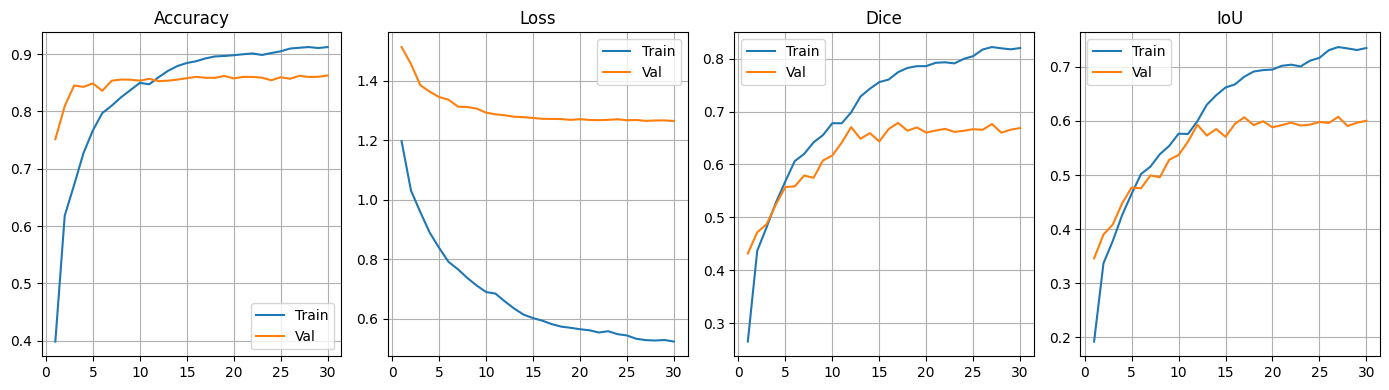

In [33]:
# ========================= 1. OVERALL METRICS =========================
plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.plot(epochs, train_acc_history, label="Train")
plt.plot(epochs, val_acc_history, label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1,4,2)
plt.plot(epochs, train_loss_history, label="Train")
plt.plot(epochs, val_loss_history, label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,4,3)
plt.plot(epochs, train_dice_history, label="Train")
plt.plot(epochs, val_dice_history, label="Val")
plt.title("Dice")
plt.legend()
plt.grid()

plt.subplot(1,4,4)
plt.plot(epochs, train_iou_history, label="Train")
plt.plot(epochs, val_iou_history, label="Val")
plt.title("IoU")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

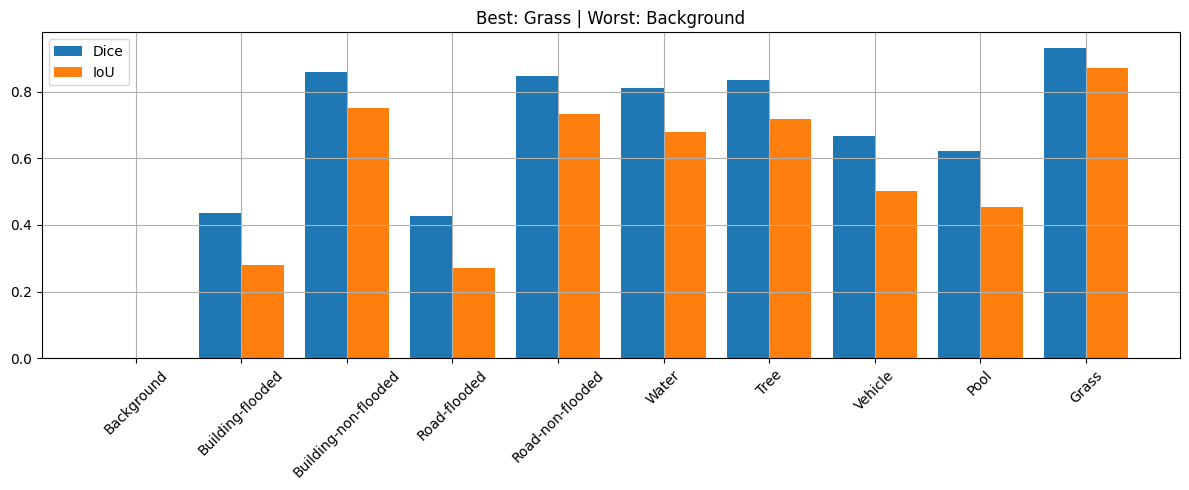

In [34]:
# ========================= 2. PER-CLASS BAR =========================
dice_cls = np.array(per_class_dice_history[-1])
iou_cls  = np.array(per_class_iou_history[-1])

x = np.arange(len(class_names))

worst_idx = np.argmin(dice_cls)
best_idx  = np.argmax(dice_cls)

plt.figure(figsize=(12,5))
plt.bar(x-0.2, dice_cls, width=0.4, label="Dice")
plt.bar(x+0.2, iou_cls,  width=0.4, label="IoU")

plt.xticks(x, class_names, rotation=45)
plt.title(f"Best: {class_names[best_idx]} | Worst: {class_names[worst_idx]}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

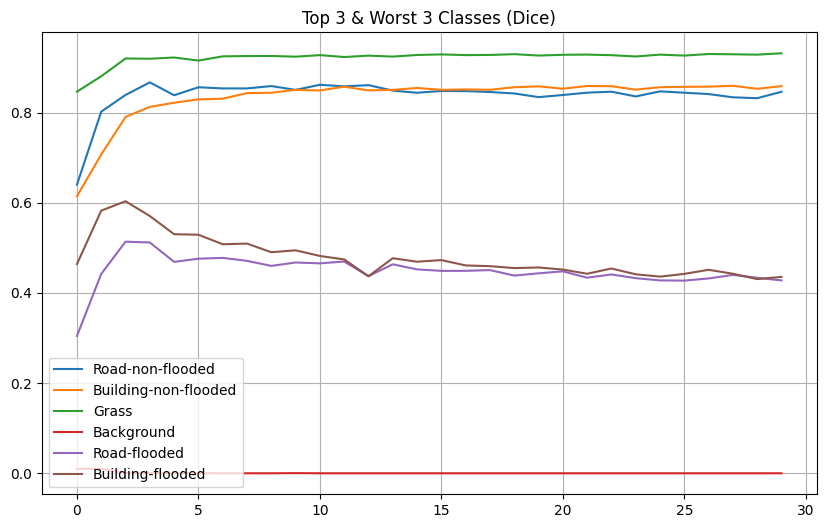

In [35]:
# ========================= 3. PER-CLASS OVER TIME =========================
per_class_dice_history_np = np.array(per_class_dice_history)

final_dice = per_class_dice_history_np[-1]

top_idx = np.argsort(final_dice)[-3:]
worst_idx = np.argsort(final_dice)[:3]

plt.figure(figsize=(10,6))

for i in list(top_idx) + list(worst_idx):
    plt.plot(per_class_dice_history_np[:, i], label=class_names[i])

plt.legend()
plt.title("Top 3 & Worst 3 Classes (Dice)")
plt.grid()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466563..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606441..2.5877123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


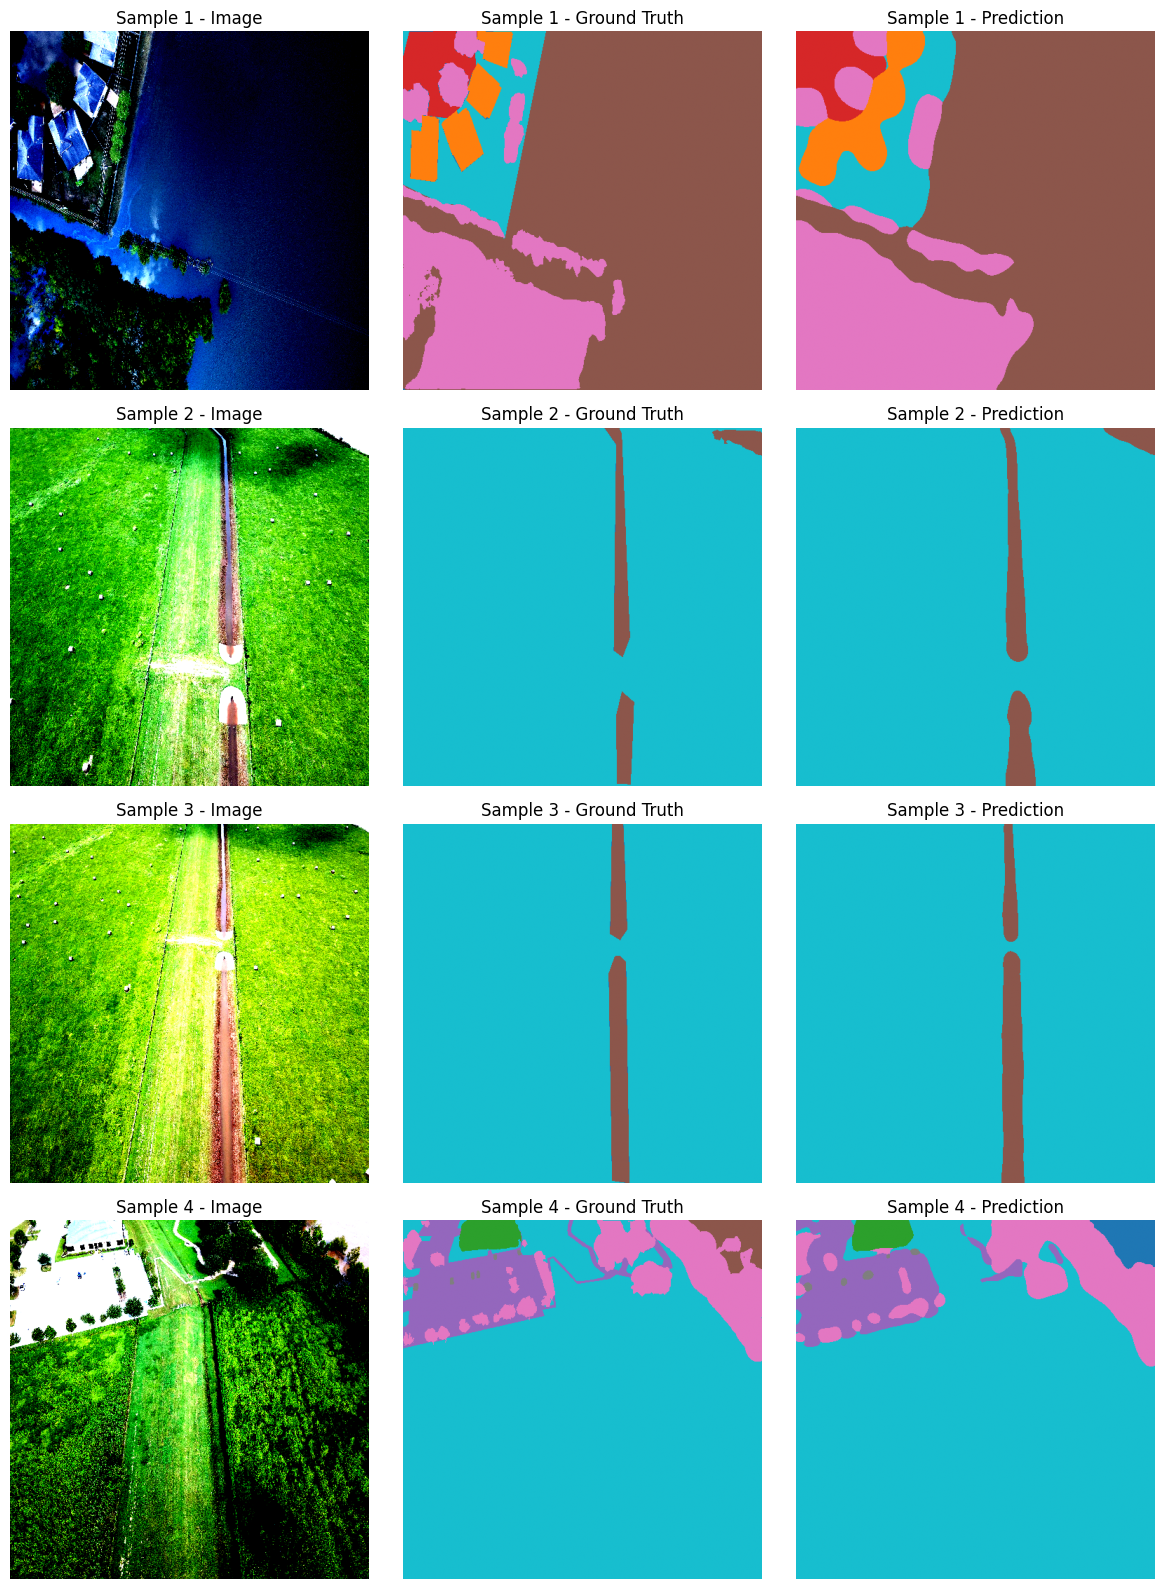

In [36]:
def visualize_samples(model, loader, num_samples=5):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)
    
    with torch.no_grad():
        outputs = tta_predict(model, images)
    preds = outputs.argmax(dim=1)

    num_samples = min(num_samples, images.size(0))

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        img  = images[i].cpu().permute(1,2,0).numpy()
        mask = masks[i].cpu().numpy()
        pred = preds[i].cpu().numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Sample {i+1} - Image")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='tab10', vmin=0, vmax=9)
        axes[i, 1].set_title(f"Sample {i+1} - Ground Truth")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred, cmap='tab10', vmin=0, vmax=9)
        axes[i, 2].set_title(f"Sample {i+1} - Prediction")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(model, val_loader, num_samples=5)

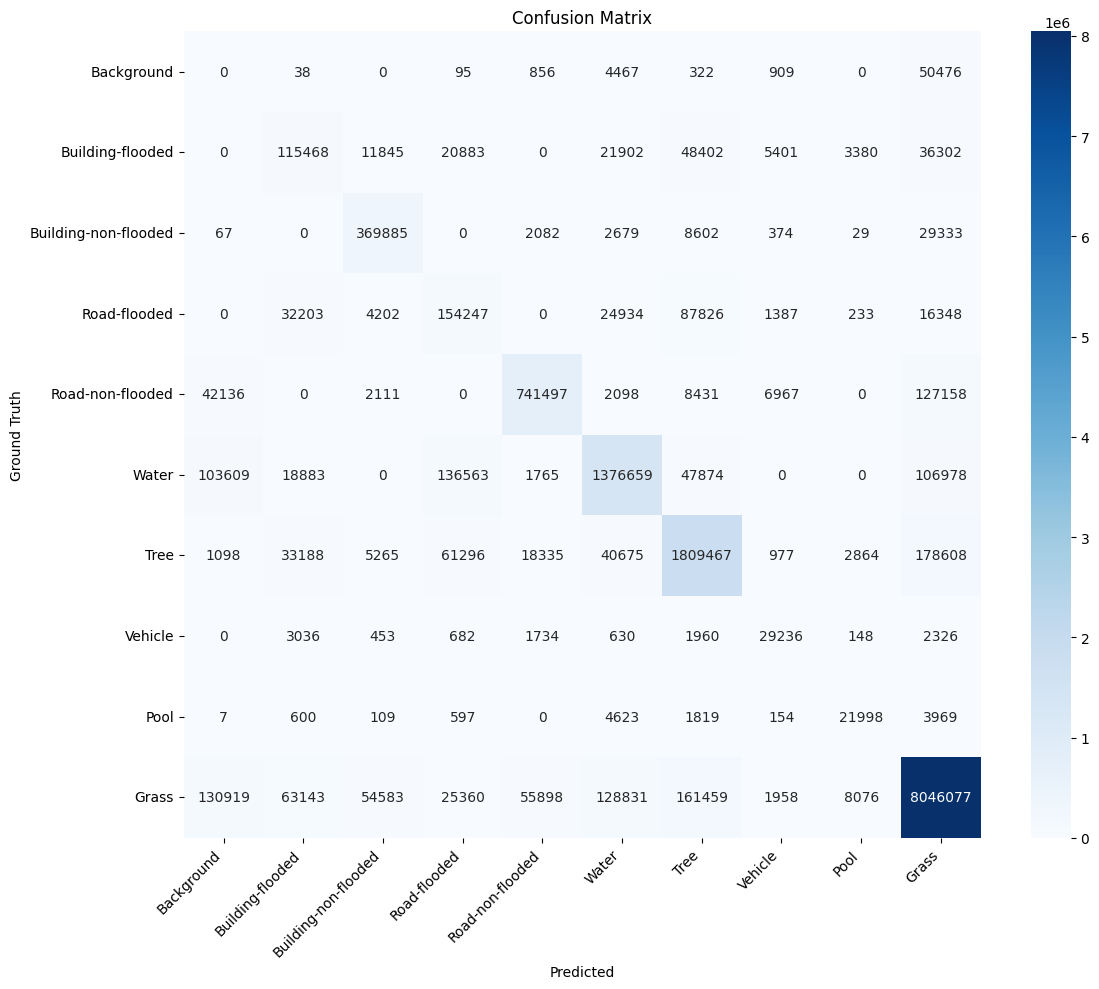

In [37]:
def plot_confusion(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for i, (images, masks) in enumerate(loader):
            try:
                images = images.to(device)
                outputs = tta_predict(model, images)
                preds = outputs.argmax(dim=1)
                all_preds.append(preds.cpu().numpy().flatten())
                all_targets.append(masks.numpy().flatten())
            except Exception as e:
                print(f"❌ lỗi batch {i}: {e}")
                continue
    if len(all_preds) == 0:
        print("❌ Không có dữ liệu hợp lệ")
        return
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Blues', annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion(model, val_loader)

In [38]:
test_dice, test_iou, test_acc = test_model(model, test_loader)

Testing: 100%|██████████| 7/7 [00:11<00:00,  1.60s/it]


===== TEST RESULT =====
Dice: 0.7265
IoU : 0.6622
Acc : 0.8625


In [39]:
def test_per_class(model, loader, num_classes=10):
    model.eval()

    dice_cls = np.zeros(num_classes)
    iou_cls  = np.zeros(num_classes)
    count = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = tta_predict(model, images)
            preds = outputs.argmax(dim=1)

            for c in range(num_classes):
                pred_c = (preds == c)
                mask_c = (masks == c)

                intersection = (pred_c & mask_c).sum().item()
                union = (pred_c | mask_c).sum().item()

                if union > 0:
                    dice_cls[c] += (2 * intersection) / (pred_c.sum().item() + mask_c.sum().item() + 1e-6)
                    iou_cls[c]  += intersection / (union + 1e-6)

            count += 1

    dice_cls /= count
    iou_cls  /= count

    return dice_cls, iou_cls



Background: Dice=0.0000, IoU=0.0000
Building-flooded: Dice=0.1256, IoU=0.0806
Building-non-flooded: Dice=0.6746, IoU=0.6396
Road-flooded: Dice=0.0988, IoU=0.0602
Road-non-flooded: Dice=0.8763, IoU=0.7827
Water: Dice=0.5740, IoU=0.5137
Tree: Dice=0.8424, IoU=0.7363
Vehicle: Dice=0.5622, IoU=0.4608
Pool: Dice=0.4805, IoU=0.4298
Grass: Dice=0.8969, IoU=0.8250


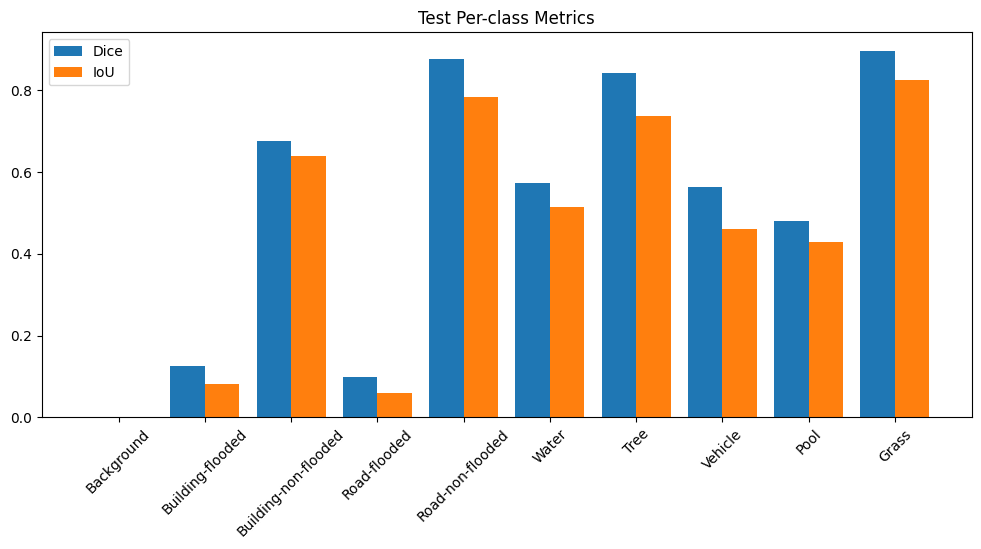

In [40]:
dice_cls, iou_cls = test_per_class(model, test_loader, num_classes=10)

for i, name in enumerate(class_names):
    print(f"{name}: Dice={dice_cls[i]:.4f}, IoU={iou_cls[i]:.4f}")

x = np.arange(len(class_names))

plt.figure(figsize=(12,5))
plt.bar(x-0.2, dice_cls, width=0.4, label="Dice")
plt.bar(x+0.2, iou_cls,  width=0.4, label="IoU")

plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.title("Test Per-class Metrics")
plt.show()

In [41]:
model.load_state_dict(torch.load("best_model_iou.pth"))

<All keys matched successfully>

In [42]:
test_dice, test_iou, test_acc = test_model(model, test_loader)
print(f"Final Test IoU: {test_iou:.4f}")


Testing: 100%|██████████| 7/7 [00:07<00:00,  1.05s/it]


===== TEST RESULT =====
Dice: 0.7269
IoU : 0.6620
Acc : 0.8665
Final Test IoU: 0.6620
